Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders ready.
Normal True
Panlobular True
Paraseptal True
Centroacinar True
Sample image: /content/drive/MyDrive/Papers/Amfizem/Normal/1.jpg


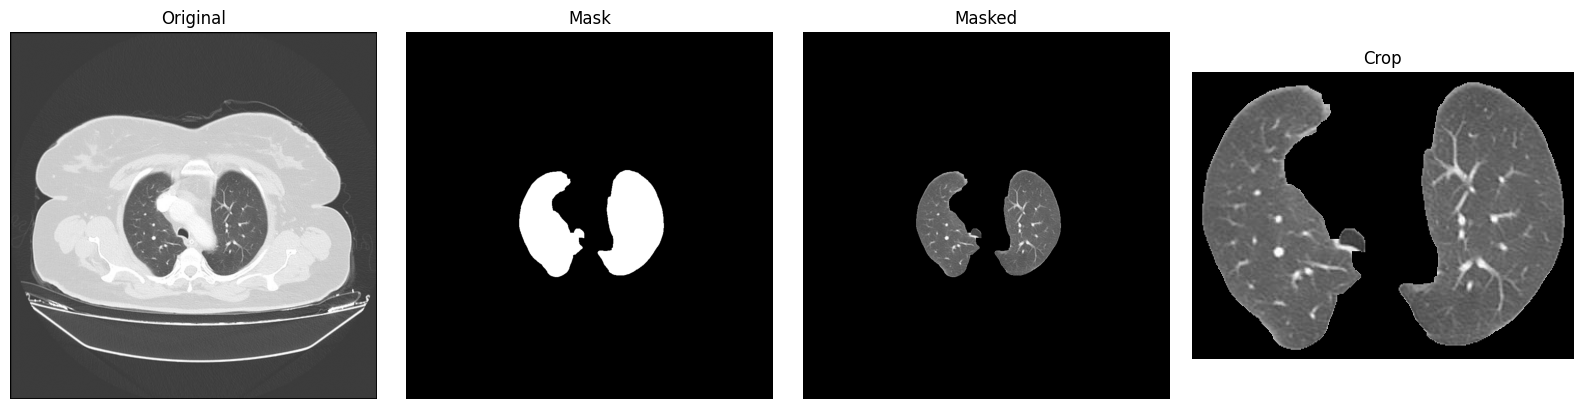

Processing Normal:   0%|          | 0/329 [00:00<?, ?it/s]

Processing Panlobular:   0%|          | 0/262 [00:00<?, ?it/s]

Processing Paraseptal:   0%|          | 0/259 [00:00<?, ?it/s]

Processing Centroacinar:   0%|          | 0/258 [00:00<?, ?it/s]


Done.
flag
ok           1096
too_large      12
Name: count, dtype: int64
QC CSV saved to: /content/drive/MyDrive/Papers/lung_segmentation_qc.csv


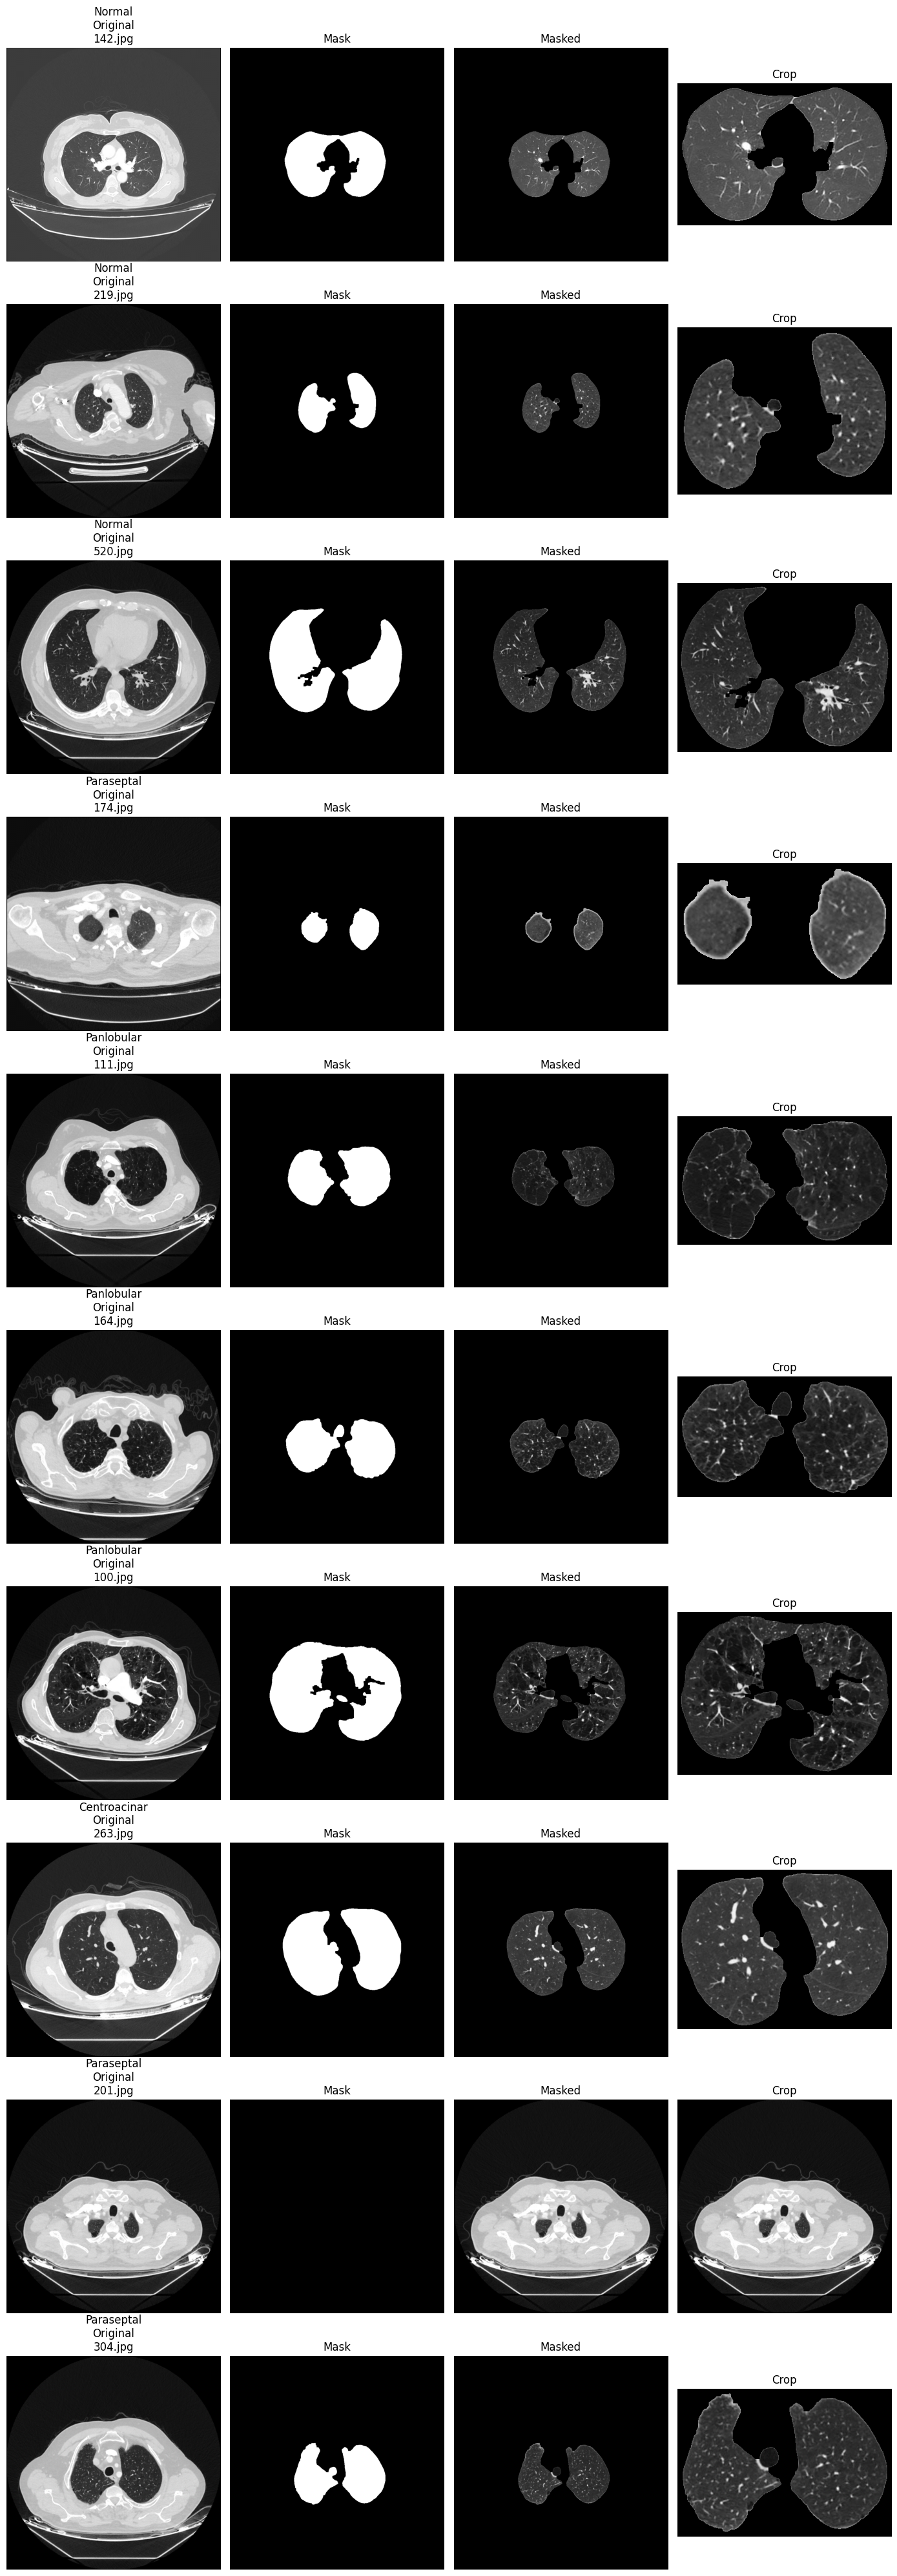


Suspicious cases: 12


,class,file_original,file_saved,mask_fraction,flag,status
656,Paraseptal,201.jpg,201.png,1.000000,too_large,ok
668,Paraseptal,216.jpg,216.png,1.000000,too_large,ok
690,Paraseptal,243.jpg,243.png,1.000000,too_large,ok
694,Paraseptal,247.jpg,247.png,1.000000,too_large,ok
721,Paraseptal,278.jpg,278.png,1.000000,too_large,ok
736,Paraseptal,296.jpg,296.png,1.000000,too_large,ok
755,Paraseptal,318.jpg,318.png,0.511119,too_large,ok
756,Paraseptal,319.jpg,319.png,1.000000,too_large,ok
764,Paraseptal,329.jpg,329.png,1.000000,too_large,ok
766,Paraseptal,330.jpg,330.png,1.000000,too_large,ok



Input vs output counts:
Normal: input=329, masks=329, masked=329, crop=329
Panlobular: input=262, masks=262, masked=262, crop=262
Paraseptal: input=259, masks=259, masked=259, crop=259
Centroacinar: input=258, masks=258, masked=258, crop=258


In [4]:

# Lung segmentation + saving masks / masked / cropped images

from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage as ndi
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import random



DATA_PATH = Path("Dataset")


class_names = ['Normal', 'Panlobular', 'Paraseptal', 'Centroacinar']

MASK_ROOT = Path("Dataset_lung_masks")
MASKED_ROOT = Path("Dataset_lung_masked")
CROP_ROOT = Path("Dataset_lung_crop")

for root in [MASK_ROOT, MASKED_ROOT, CROP_ROOT]:
    root.mkdir(parents=True, exist_ok=True)
    for c in class_names:
        (root / c).mkdir(parents=True, exist_ok=True)

print("Folders ready.")
for c in class_names:
    print(c, (DATA_PATH / c).exists())

def to_png_name(filename):
    return Path(filename).stem + ".png"

def load_gray(image_path):
    img = Image.open(image_path).convert("L")
    return np.array(img)

def apply_clahe(gray):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)

def segment_lungs_ct_slice(gray):
    """
    Classical 2D lung segmentation for chest CT JPG/PNG slices.
    Returns binary mask (0/1).
    """
    h, w = gray.shape

    # Contrast enhancement
    img = apply_clahe(gray)

    # Smooth
    blur = cv2.GaussianBlur(img, (5, 5), 0)

    # Threshold dark lung regions
    _, thresh = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel3 = np.ones((3, 3), np.uint8)
    kernel5 = np.ones((5, 5), np.uint8)

    # Morphology cleanup
    mask = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel3, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel5, iterations=2)

    # Connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    candidates = []
    for i in range(1, num_labels):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        ww = stats[i, cv2.CC_STAT_WIDTH]
        hh = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        cx = x + ww / 2
        cy = y + hh / 2

        # heuristics
        if area < 500:
            continue
        if x < 5 or y < 5 or (x + ww) > (w - 5) or (y + hh) > (h - 5):
            continue
        if not (0.15 * w < cx < 0.85 * w):
            continue
        if not (0.15 * h < cy < 0.85 * h):
            continue

        candidates.append((i, area))

    candidates = sorted(candidates, key=lambda t: t[1], reverse=True)

    mask_final = np.zeros_like(mask, dtype=np.uint8)
    for label_id, _ in candidates[:2]:
        mask_final[labels == label_id] = 1

    # Fill holes and smooth
    mask_final = ndi.binary_fill_holes(mask_final).astype(np.uint8)
    mask_final = cv2.morphologyEx(mask_final, cv2.MORPH_OPEN, kernel3, iterations=1)
    mask_final = cv2.morphologyEx(mask_final, cv2.MORPH_CLOSE, kernel5, iterations=2)
    mask_final = ndi.binary_fill_holes(mask_final).astype(np.uint8)

    return mask_final
# More permissive fallback for difficult slices, especially apical slices.
def fallback_segment_lungs(gray):
    
    h, w = gray.shape
    img = apply_clahe(gray)
    blur = cv2.GaussianBlur(img, (5, 5), 0)

    p = np.percentile(blur, 45)
    mask = (blur < p).astype(np.uint8)

    kernel3 = np.ones((3, 3), np.uint8)
    kernel7 = np.ones((7, 7), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel3, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel7, iterations=2)
    mask = ndi.binary_fill_holes(mask).astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    comps = []
    for i in range(1, num_labels):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        ww = stats[i, cv2.CC_STAT_WIDTH]
        hh = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]
        cx = x + ww / 2
        cy = y + hh / 2

        if area < 400:
            continue
        if not (0.10 * w < cx < 0.90 * w):
            continue
        if not (0.10 * h < cy < 0.90 * h):
            continue

        comps.append((i, area))

    comps = sorted(comps, key=lambda x: x[1], reverse=True)

    out = np.zeros_like(mask, dtype=np.uint8)
    for i, _ in comps[:2]:
        out[labels == i] = 1

    out = ndi.binary_fill_holes(out).astype(np.uint8)
    return out

def get_lung_mask(image_path):
    gray = load_gray(image_path)
    mask = segment_lungs_ct_slice(gray)

    frac = mask.mean()

    # fallback if too small or too large
    if frac < 0.02 or frac > 0.45:
        mask = fallback_segment_lungs(gray)
        frac = mask.mean()

    # slightly dilate very tiny masks (apical slices)
    if frac < 0.03:
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.dilate(mask.astype(np.uint8), kernel, iterations=1)
        mask = ndi.binary_fill_holes(mask).astype(np.uint8)

    return gray, mask

def crop_to_mask(image, mask, pad=10):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return image

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(image.shape[1], x2 + pad)
    y2 = min(image.shape[0], y2 + pad)

    cropped = image[y1:y2, x1:x2]

    # keep all cases: if crop is empty or invalid, return original
    if cropped.size == 0 or cropped.shape[0] < 10 or cropped.shape[1] < 10:
        return image

    return cropped

def qc_flag(mask):
    frac = mask.mean()
    if frac < 0.015:
        return "too_small"
    elif frac > 0.40:
        return "too_large"
    return "ok"


sample_image = None
for c in class_names:
    class_dir = DATA_PATH / c
    files = sorted([x for x in class_dir.iterdir() if x.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    if files:
        sample_image = str(files[0])
        break

print("Sample image:", sample_image)

gray, mask = get_lung_mask(sample_image)
masked = gray.copy()
masked[mask == 0] = 0
crop = crop_to_mask(masked, mask, pad=10)

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(masked, cmap="gray")
plt.title("Masked")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(crop, cmap="gray")
plt.title("Crop")
plt.axis("off")

plt.tight_layout()
plt.show()

#  Process all images and save as PNG
rows = []

for c in class_names:
    class_dir = DATA_PATH / c
    image_files = sorted([x for x in class_dir.iterdir() if x.suffix.lower() in [".jpg", ".jpeg", ".png"]])

    for img_path in tqdm(image_files, desc=f"Processing {c}"):
        png_name = to_png_name(img_path.name)

        try:
            gray, mask = get_lung_mask(str(img_path))

            masked = gray.copy()
            masked[mask == 0] = 0
            crop = crop_to_mask(masked, mask, pad=10)

            # save all outputs
            Image.fromarray((mask * 255).astype(np.uint8)).save(MASK_ROOT / c / png_name)
            Image.fromarray(masked.astype(np.uint8)).save(MASKED_ROOT / c / png_name)
            Image.fromarray(crop.astype(np.uint8)).save(CROP_ROOT / c / png_name)

            rows.append({
                "class": c,
                "file_original": img_path.name,
                "file_saved": png_name,
                "mask_fraction": float(mask.mean()),
                "flag": qc_flag(mask),
                "status": "ok"
            })

        except Exception as e:
            
            try:
                gray = load_gray(str(img_path))
                full_mask = np.ones_like(gray, dtype=np.uint8) * 255

                Image.fromarray(full_mask.astype(np.uint8)).save(MASK_ROOT / c / png_name)
                Image.fromarray(gray.astype(np.uint8)).save(MASKED_ROOT / c / png_name)
                Image.fromarray(gray.astype(np.uint8)).save(CROP_ROOT / c / png_name)

                rows.append({
                    "class": c,
                    "file_original": img_path.name,
                    "file_saved": png_name,
                    "mask_fraction": 1.0,
                    "flag": "error_saved_original",
                    "status": f"fallback_saved_original: {str(e)}"
                })
            except Exception as e2:
                rows.append({
                    "class": c,
                    "file_original": img_path.name,
                    "file_saved": png_name,
                    "mask_fraction": None,
                    "flag": "fatal_error",
                    "status": str(e2)
                })

qc_df = pd.DataFrame(rows)

qc_df.to_csv("lung_segmentation_qc.csv", index=False)

print("\nDone.")
print(qc_df["flag"].value_counts(dropna=False))
print(f"QC CSV saved to: {qc_csv_path}")


all_images = []
for c in class_names:
    class_dir = DATA_PATH / c
    files = sorted([x for x in class_dir.iterdir() if x.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    for f in files:
        all_images.append((c, f))

samples = random.sample(all_images, min(10, len(all_images)))

fig, axes = plt.subplots(len(samples), 4, figsize=(14, 4 * len(samples)))

if len(samples) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, (c, img_path) in enumerate(samples):
    try:
        gray, mask = get_lung_mask(str(img_path))
        masked = gray.copy()
        masked[mask == 0] = 0
        crop = crop_to_mask(masked, mask, pad=10)
    except:
        gray = load_gray(str(img_path))
        mask = np.ones_like(gray, dtype=np.uint8)
        masked = gray.copy()
        crop = gray.copy()

    axes[row, 0].imshow(gray, cmap="gray")
    axes[row, 0].set_title(f"{c}\nOriginal\n{img_path.name}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Mask")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(masked, cmap="gray")
    axes[row, 2].set_title("Masked")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(crop, cmap="gray")
    axes[row, 3].set_title("Crop")
    axes[row, 3].axis("off")

plt.tight_layout()
plt.show()

# Inspect suspicious masks 
bad_df = qc_df[qc_df["flag"] != "ok"].copy()
print("\nSuspicious cases:", len(bad_df))
display(bad_df.head(50))

# 10) Verify input/output counts
print("\nInput vs output counts:")
for c in class_names:
    in_count = len([x for x in (DATA_PATH / c).iterdir() if x.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    mask_count = len([x for x in (MASK_ROOT / c).iterdir() if x.suffix.lower() == ".png"])
    masked_count = len([x for x in (MASKED_ROOT / c).iterdir() if x.suffix.lower() == ".png"])
    crop_count = len([x for x in (CROP_ROOT / c).iterdir() if x.suffix.lower() == ".png"])

    print(f"{c}: input={in_count}, masks={mask_count}, masked={masked_count}, crop={crop_count}")

In [3]:
import json
from pathlib import Path

notebook_path = Path("Segmentation.ipynb")

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(notebook_path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)

print("metadata.widgets removed successfully.")

metadata.widgets removed successfully.
